In [2]:
import numpy as np
import matplotlib.pyplot as plt
from empymod import bipole


:: empymod END; runtime = 0:00:00.137072 :: 768 kernel call(s)



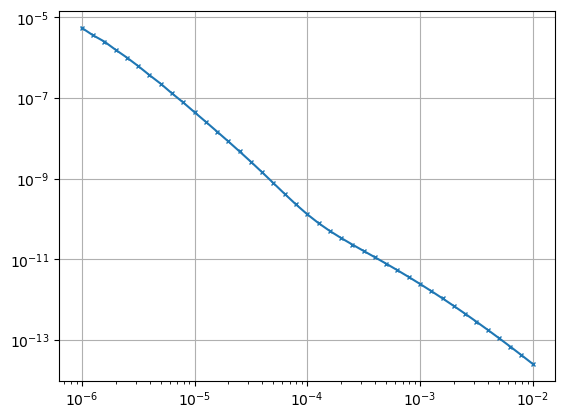

In [36]:
time = np.logspace(-6, -2, 41)
L = 40
tx = [-L/2, L/2, L/2, -L/2, -L/2]
ty = [L/2, L/2, -L/2, -L/2, L/2]
out = bipole(
    res=[2e14, 100, 10],
    depth=[0, 100],
    src=[tx[:-1], tx[1:], ty[:-1], ty[1:], 0, 0],
    rec=[0, 0, 0, 0, 90], # z directed receiver in origin
    strength=1/L**2,
    signal=-1,
    mrec="b",
    freqtime=time, # Wanted times.
    srcpts=3,
    ftarg={"dlf": "key_81_2009"},  # Shorter, faster filters.
    htarg={"dlf": "key_101_2009", "pts_per_dec": -1},
    ).sum(axis=1)
plt.loglog(time, out, "x-")
plt.grid()

[Script EM](https://tubaf-em.github.io/Geoelektrik_Elektromagnetik/tem.html):

$$
\rho_{a} = \frac{\mu_{0}}{\pi} \left( \frac{m}{20 t^{2}} \right)^{3/2} \left( \frac{ -\partial H_{z} }{ \partial t }  \right)  ^{-2/3}
$$

$$
\rho_{a} = \frac{\mu_{0}}{\pi} \left( \frac{\mu_0 m}{20} \right)^{2/3} \left( \frac{ \partial B_{z} }{ \partial t }  \right)^{-2/3} * t^{-5/3}
$$


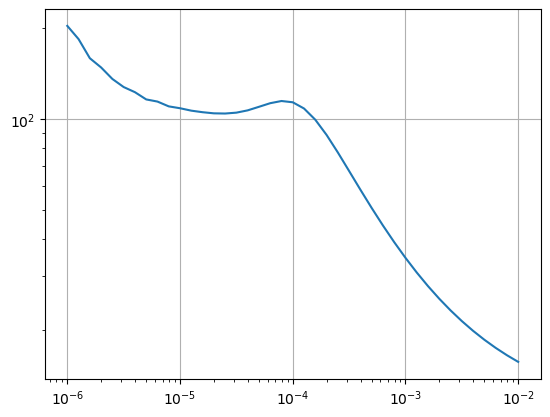

In [37]:
def rhoa(t, dbzdt, m=1.0):
    mu0 = np.pi*4e-7
    return mu0 / np.pi * (mu0 * m / 20.0)**(2/3) * np.abs(dbzdt)**(-2/3) * t**(-5/3)

plt.loglog(time, rhoa(time, out))
plt.grid()